In [35]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import time

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype = torch.float64
torch.set_default_dtype(dtype)

print(f"PyTorch: {torch.__version__}")
print(f"Device:  {device}")

PyTorch: 2.8.0+cu128
Device:  cuda


In [36]:
# =================== Geometry ===================
L_geom = 60.0    # mm
W_geom = 20.0    # mm
T_geom = 3.0     # mm

# =================== HGO material parameters ===================

C10   = 0.060672  # MPa  
k1    = 0.797698   # MPa  
k2    = 6.15605   #      
kappa = 0.0        #      
D_p   = 0.1      # MPa^-1  

gamma_deg = 49.2   #      
gamma_rad = np.deg2rad(gamma_deg)

L_vec = torch.tensor([np.cos(gamma_rad),  np.sin(gamma_rad), 0.0], dtype=dtype, device=device)
M_vec = torch.tensor([np.cos(gamma_rad), -np.sin(gamma_rad), 0.0], dtype=dtype, device=device)

# =================== Mullins parameters===================


r_mul    = 1.149988   # 
m_load   = 0.018227   # MPa  
m_unload = 0.011671   # MPa  
beta_mul = 0.385
# =================== sampling points ===================
nx, ny, nz =61, 21, 7

# =================== load ===================
delta_max   = 30.00
n_cycle     = 20
n_cycles    = 5
delta_peaks = [6.0, 12.0, 18.0, 24.0, 30.0]

print(f"Geometry:     {L_geom} × {W_geom} × {T_geom} mm")
print(f"Total points: {nx*ny*nz}")
print(f"Max stretch:  λ_max = {1 + delta_max/L_geom:.3f}")
print(f"Total steps:  {n_cycles * 2 * n_cycle}")
print(f"Mullins:      m_load={m_load}, m_unload={m_unload} (dual-m for hysteresis)")


Geometry:     60.0 × 20.0 × 3.0 mm
Total points: 8967
Max stretch:  λ_max = 1.500
Total steps:  200
Mullins:      m_load=0.018227, m_unload=0.011671 (dual-m for hysteresis)


## 2. Generate sampling points

In [37]:
def generate_collocation_points(nx, ny, nz, L, W, T):
    x1 = torch.linspace(0, L, nx, dtype=dtype, device=device)
    x2 = torch.linspace(0, W, ny, dtype=dtype, device=device)
    x3 = torch.linspace(0, T, nz, dtype=dtype, device=device)
    X1, X2, X3 = torch.meshgrid(x1, x2, x3, indexing='ij')
    X = torch.stack([X1.flatten(), X2.flatten(), X3.flatten()], dim=1)
    
    def trap_w(n, length):
        w = torch.ones(n, dtype=dtype, device=device) * length/(n-1)
        w[0] *= 0.5
        w[-1] *= 0.5
        return w
    
    w1 = trap_w(nx, L); w2 = trap_w(ny, W); w3 = trap_w(nz, T)
    W3D = torch.einsum('i,j,k->ijk', w1, w2, w3).flatten()
    return X, W3D

X_int, W3D = generate_collocation_points(nx, ny, nz, L_geom, W_geom, T_geom)
N = X_int.shape[0]
print(f"X_int shape: {X_int.shape}")
print(f"Volume: {W3D.sum().item():.2f} (expected {L_geom*W_geom*T_geom})")

X_int shape: torch.Size([8967, 3])
Volume: 3600.00 (expected 3600.0)


In [38]:
class DEM_Network(nn.Module):
    def __init__(self, layers=[3, 64, 64, 64, 64, 64, 3]):
        super().__init__()
        self.layers_list = layers
        mods = []
        for i in range(len(layers)-1):
            mods.append(nn.Linear(layers[i], layers[i+1]))
            if i < len(layers)-2:
                mods.append(nn.Tanh())
        self.net = nn.Sequential(*mods).to(dtype=dtype, device=device)
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, X):
        X_norm = torch.stack([
            2*X[:,0]/L_geom - 1,
            2*X[:,1]/W_geom - 1,
            2*X[:,2]/T_geom - 1
        ], dim=1)
        return self.net(X_norm)

net = DEM_Network()
print(f"Network: {net.layers_list}")
print(f"Params:  {sum(p.numel() for p in net.parameters())}")

Network: [3, 64, 64, 64, 64, 64, 3]
Params:  17091


In [39]:
def apply_hard_BC(X, y_hat, delta):
    xi1 = X[:,0] / L_geom
    xi2 = X[:,1] / W_geom
    xi3 = X[:,2] / T_geom
    u1 = xi1 * delta + xi1 * (1 - xi1) * y_hat[:, 0]
    u2 = xi2 * y_hat[:, 1]
    u3 = xi3 * y_hat[:, 2]
    return torch.stack([u1, u2, u3], dim=1)

In [40]:
def compute_kinematics(X, u_hat):
    grad_u = torch.zeros(X.shape[0], 3, 3, dtype=dtype, device=device)
    for i in range(3):
        gi = torch.autograd.grad(
            u_hat[:, i].sum(), X, create_graph=True, retain_graph=True
        )[0]
        grad_u[:, i, :] = gi
    
    I3 = torch.eye(3, dtype=dtype, device=device).unsqueeze(0)
    F = I3 + grad_u
    J = torch.det(F).clamp(min=1e-6)
    F_bar = J.pow(-1.0/3.0).view(-1, 1, 1) * F
    C_bar = torch.bmm(F_bar.transpose(-1, -2), F_bar)
    
    I1_bar  = torch.diagonal(C_bar, dim1=-2, dim2=-1).sum(-1)
    I41_bar = torch.einsum('i,nij,j->n', L_vec, C_bar, L_vec)
    I42_bar = torch.einsum('i,nij,j->n', M_vec, C_bar, M_vec)
    
    return F, J, I1_bar, I41_bar, I42_bar

In [41]:
def hgo_energy(I1_bar, I41_bar, I42_bar, J):
    psi_iso = C10 * (I1_bar - 3.0)
    
    E1_bar = kappa*(I1_bar - 3.0) + (1.0 - 3.0*kappa)*(I41_bar - 1.0)
    E2_bar = kappa*(I1_bar - 3.0) + (1.0 - 3.0*kappa)*(I42_bar - 1.0)
    
    E1_pos = torch.nn.functional.softplus(E1_bar, beta=50.0)
    E2_pos = torch.nn.functional.softplus(E2_bar, beta=50.0)
    
    psi_aniso = (k1 / (2.0*k2)) * (
        (torch.exp(k2 * E1_pos**2) - 1.0) +
        (torch.exp(k2 * E2_pos**2) - 1.0)
    )
    psi_vol = (1.0/D_p) * ((J**2 - 1.0)/2.0 - torch.log(J))
    
    psi_dev = psi_iso + psi_aniso
    return psi_dev, psi_vol

In [42]:
def compute_mullins_eta(psi_dev, psi_max, is_loading):

    m_current = m_load if is_loading else m_unload
    denom = m_current + beta_mul * psi_max + 1e-10
    arg = (psi_max - psi_dev) / denom
    arg = torch.clamp(arg, min=0.0, max=5.0)
    return 1.0 - (1.0/r_mul) * torch.erf(arg)

In [43]:
def compute_total_energy(X, delta_t, psi_max, net, is_loading=True):
    X = X.requires_grad_(True)
    y_hat = net(X)
    u_hat = apply_hard_BC(X, y_hat, delta_t)
    F, J, I1, I41, I42 = compute_kinematics(X, u_hat)
    psi_dev, psi_vol = hgo_energy(I1, I41, I42, J)
    eta = compute_mullins_eta(psi_dev, psi_max, is_loading).detach()
    psi_aug = eta * psi_dev + psi_vol
    E_total = (W3D * psi_aug).sum()
    return E_total, psi_dev, eta, F, J

def extract_reaction_stress(net, delta_value, psi_max, is_loading=True):
    delta_t = torch.tensor(float(delta_value), dtype=dtype, device=device,
                            requires_grad=True)
    E, _, _, _, _ = compute_total_energy(X_int.clone(), delta_t, psi_max, net, is_loading)
    reaction = torch.autograd.grad(E, delta_t)[0]
    P11 = reaction.item() / (W_geom * T_geom)
    F11 = 1.0 + delta_value / L_geom
    return F11, P11

In [44]:
def solve_one_step(net, delta_value, psi_max, is_loading=True,
                   adam_max=600, lbfgs_max=150,
                   adam_lr=5e-4, plateau_tol=1e-10,
                   plateau_patience=50, verbose=False):
    # ---- Adam with early stopping ----
    opt_adam = torch.optim.Adam(net.parameters(), lr=adam_lr)
    best_loss = float('inf')
    plateau_count = 0
    loss_history = []
    
    for ep in range(adam_max):
        opt_adam.zero_grad()
        E, _, _, _, _ = compute_total_energy(X_int.clone(), delta_value, psi_max, net, is_loading)
        E.backward()
        opt_adam.step()
        
        loss_val = E.item()
        loss_history.append(loss_val)
        
        if abs(best_loss - loss_val) < plateau_tol * max(1.0, abs(best_loss)):
            plateau_count += 1
            if plateau_count >= plateau_patience:
                if verbose:
                    print(f"    Adam early stop @ ep {ep}, loss = {loss_val:.4e}")
                break
        else:
            plateau_count = 0
        best_loss = min(best_loss, loss_val)
    
    # ---- L-BFGS ----
    opt_lbfgs = torch.optim.LBFGS(
        net.parameters(), lr=1.0, max_iter=lbfgs_max,
        tolerance_grad=1e-11, tolerance_change=1e-14,
        history_size=100, line_search_fn='strong_wolfe'
    )
    
    def closure():
        opt_lbfgs.zero_grad()
        E, _, _, _, _ = compute_total_energy(X_int.clone(), delta_value, psi_max, net, is_loading)
        E.backward()
        return E
    
    final_loss = opt_lbfgs.step(closure)
    loss_history.append(final_loss.item())
    return loss_history

In [45]:
def analytical_uniaxial(F11_val, lam_lat, psi_max_val=0.0, is_loading=True):
    F = torch.diag(torch.tensor([F11_val, lam_lat, lam_lat], dtype=dtype, device=device))
    F.requires_grad_(True)
    
    J = torch.det(F)
    F_bar = J.pow(-1/3) * F
    C_bar = F_bar.T @ F_bar
    I1 = torch.trace(C_bar)
    I41 = L_vec @ C_bar @ L_vec
    I42 = M_vec @ C_bar @ M_vec
    
    psi_iso = C10 * (I1 - 3)
    E1 = kappa*(I1-3) + (1-3*kappa)*(I41-1)
    E2 = kappa*(I1-3) + (1-3*kappa)*(I42-1)
    E1p = torch.nn.functional.softplus(E1, beta=50)
    E2p = torch.nn.functional.softplus(E2, beta=50)
    psi_aniso = (k1/(2*k2)) * ((torch.exp(k2*E1p**2) - 1) + (torch.exp(k2*E2p**2) - 1))
    psi_vol = (1/D_p) * ((J**2 - 1)/2 - torch.log(J))
    psi_dev = psi_iso + psi_aniso
    
    m_current = m_load if is_loading else m_unload
    pm_t = torch.tensor(psi_max_val, dtype=dtype, device=device)
    arg = torch.clamp((pm_t - psi_dev)/(m_current+beta_mul*pm_t+1e-10), min=0.0, max=5.0)
    eta = 1.0 - (1.0/r_mul) * torch.erf(arg)
    psi_aug = eta * psi_dev + psi_vol
    
    P = torch.autograd.grad(psi_aug, F)[0]
    return P[0,0].item(), P[1,1].item(), psi_dev.item()

def find_equilibrium_lam_lat(F11_val, psi_max_val=0.0, is_loading=True):
    def f(ll):
        _, P22, _ = analytical_uniaxial(F11_val, ll, psi_max_val, is_loading)
        return P22
    try:
        return brentq(f, 0.5, 1.5, xtol=1e-7)
    except:
        return 1.0/np.sqrt(F11_val)


def build_analytical_reference():
    F11_grid = np.linspace(1.0, 1 + delta_max/L_geom, 51)

    
    # Virgin loading
    P11_virgin = []
    peak_psi = 0.0
    for F11 in F11_grid:
        ll = find_equilibrium_lam_lat(F11, 0.0, True)
        P11, _, psi_d = analytical_uniaxial(F11, ll, 0.0, True)
        P11_virgin.append(P11)
        peak_psi = max(peak_psi, psi_d)
    
    # Unloading (m_unload)
    P11_unload = []
    for F11 in F11_grid:
        ll = find_equilibrium_lam_lat(F11, peak_psi, False)
        P11, _, _ = analytical_uniaxial(F11, ll, peak_psi, False)
        P11_unload.append(P11)
    
    # Reloading (m_load, but psi_max at peak)
    P11_reload = []
    for F11 in F11_grid:
        ll = find_equilibrium_lam_lat(F11, peak_psi, True)
        P11, _, _ = analytical_uniaxial(F11, ll, peak_psi, True)
        P11_reload.append(P11)
    
    return F11_grid, np.array(P11_virgin), np.array(P11_unload), np.array(P11_reload), peak_psi

print("Computing analytical reference (dual-m)...")
F11_ref, P11_load_ref, P11_unload_ref, P11_reload_ref, peak_psi = build_analytical_reference()
print(f"Done. Peak psi_dev = {peak_psi:.4f}")
print(f"At F11=1.10:")
idx_110 = np.argmin(np.abs(F11_ref - 1.10))
print(f"  P_load   = {P11_load_ref[idx_110]:.4f}")
print(f"  P_unload = {P11_unload_ref[idx_110]:.4f}")
print(f"  P_reload = {P11_reload_ref[idx_110]:.4f}")
print(f"  Hysteresis gap = {P11_reload_ref[idx_110] - P11_unload_ref[idx_110]:.4f} MPa")

Computing analytical reference (dual-m)...
Done. Peak psi_dev = 0.1666
At F11=1.10:
  P_load   = 0.0328
  P_unload = 0.0043
  P_reload = 0.0044
  Hysteresis gap = 0.0001 MPa


In [46]:
delta_all = []
phase_all = []

clustering = 1.5   # Encryption strength at the unloading end: 1 = uniform; 
# higher values mean concentration toward the peak end (2~3 is recommended).

for peak in delta_peaks:
    # Loading section: Keep uniform
    d_load = np.linspace(peak / n_cycle, peak, n_cycle)


    s = np.linspace(0.0, 1.0, n_cycle + 1)[1:]   
    s_warp = s ** clustering                      
    d_unload = peak * (1.0 - s_warp)              

    delta_all.extend(d_load)
    phase_all.extend(['load'] * n_cycle)
    delta_all.extend(d_unload)
    phase_all.extend(['unload'] * n_cycle)

load_schedule = np.array(delta_all)
phase_labels  = phase_all

print(f"Total steps: {len(load_schedule)}")
step_idx = 0
for i, peak in enumerate(delta_peaks):
    n_seg = 2 * n_cycle
    print(f"  Cycle {i+1}: step {step_idx+1}-{step_idx+n_seg}  "
          f"Load 0→{peak:.0f}mm, Unload {peak:.0f}→0mm")
    step_idx += n_seg

print("\n卸载段加密后取值 (clustering = {:.2f}):".format(clustering))
step_idx = 0
for i, peak in enumerate(delta_peaks):
    n_seg = 2 * n_cycle
    seg = load_schedule[step_idx + n_cycle : step_idx + n_seg]   
    lam = 1.0 + seg / L_geom                                     
    dstep = np.abs(np.diff(np.r_[peak, seg]))                    

    print(f"\n  Cycle {i+1}  (peak δ={peak:.1f}mm, λ_max={1+peak/L_geom:.4f})")
    print("    idx |    δ(mm) |    λ    | |Δδ|(mm)")
    for j in range(n_cycle):
        print(f"    {j+1:3d} | {seg[j]:8.3f} | {lam[j]:.4f} | {dstep[j]:7.3f}")
    step_idx += n_seg



Total steps: 200
  Cycle 1: step 1-40  Load 0→6mm, Unload 6→0mm
  Cycle 2: step 41-80  Load 0→12mm, Unload 12→0mm
  Cycle 3: step 81-120  Load 0→18mm, Unload 18→0mm
  Cycle 4: step 121-160  Load 0→24mm, Unload 24→0mm
  Cycle 5: step 161-200  Load 0→30mm, Unload 30→0mm

卸载段加密后取值 (clustering = 1.50):

  Cycle 1  (peak δ=6.0mm, λ_max=1.1000)
    idx |    δ(mm) |    λ    | |Δδ|(mm)
      1 |    5.933 | 1.0989 |   0.067
      2 |    5.810 | 1.0968 |   0.123
      3 |    5.651 | 1.0942 |   0.159
      4 |    5.463 | 1.0911 |   0.188
      5 |    5.250 | 1.0875 |   0.213
      6 |    5.014 | 1.0836 |   0.236
      7 |    4.758 | 1.0793 |   0.256
      8 |    4.482 | 1.0747 |   0.276
      9 |    4.189 | 1.0698 |   0.293
     10 |    3.879 | 1.0646 |   0.310
     11 |    3.553 | 1.0592 |   0.326
     12 |    3.211 | 1.0535 |   0.341
     13 |    2.856 | 1.0476 |   0.356
     14 |    2.486 | 1.0414 |   0.370
     15 |    2.103 | 1.0350 |   0.383
     16 |    1.707 | 1.0284 |   0.396
     17 |  

In [47]:
# ===== Initialize =====
torch.manual_seed(42)
np.random.seed(42)
net = DEM_Network()
psi_max = torch.zeros(N, dtype=dtype, device=device)

results = {
    'step': [], 'delta': [], 'phase': [],
    'F11': [], 'P11': [], 'eta_mean': [],
    'psi_max_mean': [], 'loss_final': [], 'loss_hist': []
}

t_start = time.time()
prev_phase = None
delta_prev = 0.0

for step, (delta_curr, phase) in enumerate(zip(load_schedule, phase_labels)):
    delta_curr = float(delta_curr)
    is_phase_switch = (prev_phase is not None and phase != prev_phase)
    

    is_loading = (delta_curr >= delta_prev)
    

    cycle_step = step % (2 * n_cycle)
    approaching_peak = (phase == 'load' and cycle_step >= n_cycle - 3)

    if step == 0:
        adam_eps, lbfgs_it = 4000, 600
    elif is_phase_switch or approaching_peak:
        adam_eps, lbfgs_it = 500, 200
    else:
        adam_eps, lbfgs_it = 500, 200

    
    loss_hist = solve_one_step(
        net, delta_curr, psi_max,
        is_loading=is_loading,
        adam_max=adam_eps,
        lbfgs_max=lbfgs_it,
        adam_lr=5e-4,
        plateau_tol=1e-10,
        plateau_patience=50,
        verbose=False
    )
    
    # ===== Stress extraction =====
    F11, P11 = extract_reaction_stress(net, delta_curr, psi_max, is_loading)
    
    # ===== Update history =====
    X_e = X_int.clone().requires_grad_(True)
    y_e = net(X_e)
    u_e = apply_hard_BC(X_e, y_e, delta_curr)
    F_e, J_e, I1_e, I41_e, I42_e = compute_kinematics(X_e, u_e)
    psi_dev_e, _ = hgo_energy(I1_e, I41_e, I42_e, J_e)
    eta_e = compute_mullins_eta(psi_dev_e, psi_max, is_loading)
    
    psi_max = torch.maximum(psi_max, psi_dev_e.detach())
    eta_mean = eta_e.detach().mean().item()
    
    results['step'].append(step+1)
    results['delta'].append(delta_curr)
    results['phase'].append(phase)
    results['F11'].append(F11)
    results['P11'].append(P11)
    results['eta_mean'].append(eta_mean)
    results['psi_max_mean'].append(psi_max.mean().item())
    results['loss_final'].append(loss_hist[-1])
    results['loss_hist'].append(np.asarray(loss_hist, dtype=float))
    
    # Logging
    if (step+1) % 3 == 0 or step == 0 or step == len(load_schedule)-1 or is_phase_switch:
        elapsed = time.time() - t_start
        direction = "↑" if is_loading else "↓"
        marker = ""
        if is_phase_switch: marker += " ← SWITCH"
        if approaching_peak: marker += " ← PEAK BOOST"
        print(f"Step {step+1:3d}/{len(load_schedule)} | {phase:6s} {direction} | δ={delta_curr:6.2f}mm | "
              f"F11={F11:.4f} | P11={P11:.4f} MPa | η={eta_mean:.3f} | "
              f"loss={loss_hist[-1]:.2e} | t={elapsed:.0f}s{marker}")
    
    delta_prev = delta_curr
    prev_phase = phase

t_total = time.time() - t_start
print(f"\n=== Total time: {t_total:.0f} s ({t_total/60:.1f} min) ===")

Step   1/200 | load   ↑ | δ=  0.30mm | F11=1.0050 | P11=0.0033 MPa | η=1.000 | loss=3.60e-01 | t=182s
Step   3/200 | load   ↑ | δ=  0.90mm | F11=1.0150 | P11=0.0072 MPa | η=1.000 | loss=5.48e-01 | t=241s
Step   6/200 | load   ↑ | δ=  1.80mm | F11=1.0300 | P11=0.0129 MPa | η=1.000 | loss=1.09e+00 | t=331s
Step   9/200 | load   ↑ | δ=  2.70mm | F11=1.0450 | P11=0.0187 MPa | η=1.000 | loss=1.94e+00 | t=421s
Step  12/200 | load   ↑ | δ=  3.60mm | F11=1.0600 | P11=0.0244 MPa | η=1.000 | loss=3.11e+00 | t=512s
Step  15/200 | load   ↑ | δ=  4.50mm | F11=1.0750 | P11=0.0302 MPa | η=1.000 | loss=4.58e+00 | t=605s
Step  18/200 | load   ↑ | δ=  5.40mm | F11=1.0900 | P11=0.0361 MPa | η=1.000 | loss=6.37e+00 | t=698s ← PEAK BOOST
Step  21/200 | unload ↓ | δ=  5.93mm | F11=1.0989 | P11=0.0415 MPa | η=0.996 | loss=7.56e+00 | t=778s ← SWITCH
Step  24/200 | unload ↓ | δ=  5.46mm | F11=1.0911 | P11=0.0356 MPa | η=0.973 | loss=6.34e+00 | t=834s
Step  27/200 | unload ↓ | δ=  4.76mm | F11=1.0793 | P11=0.03

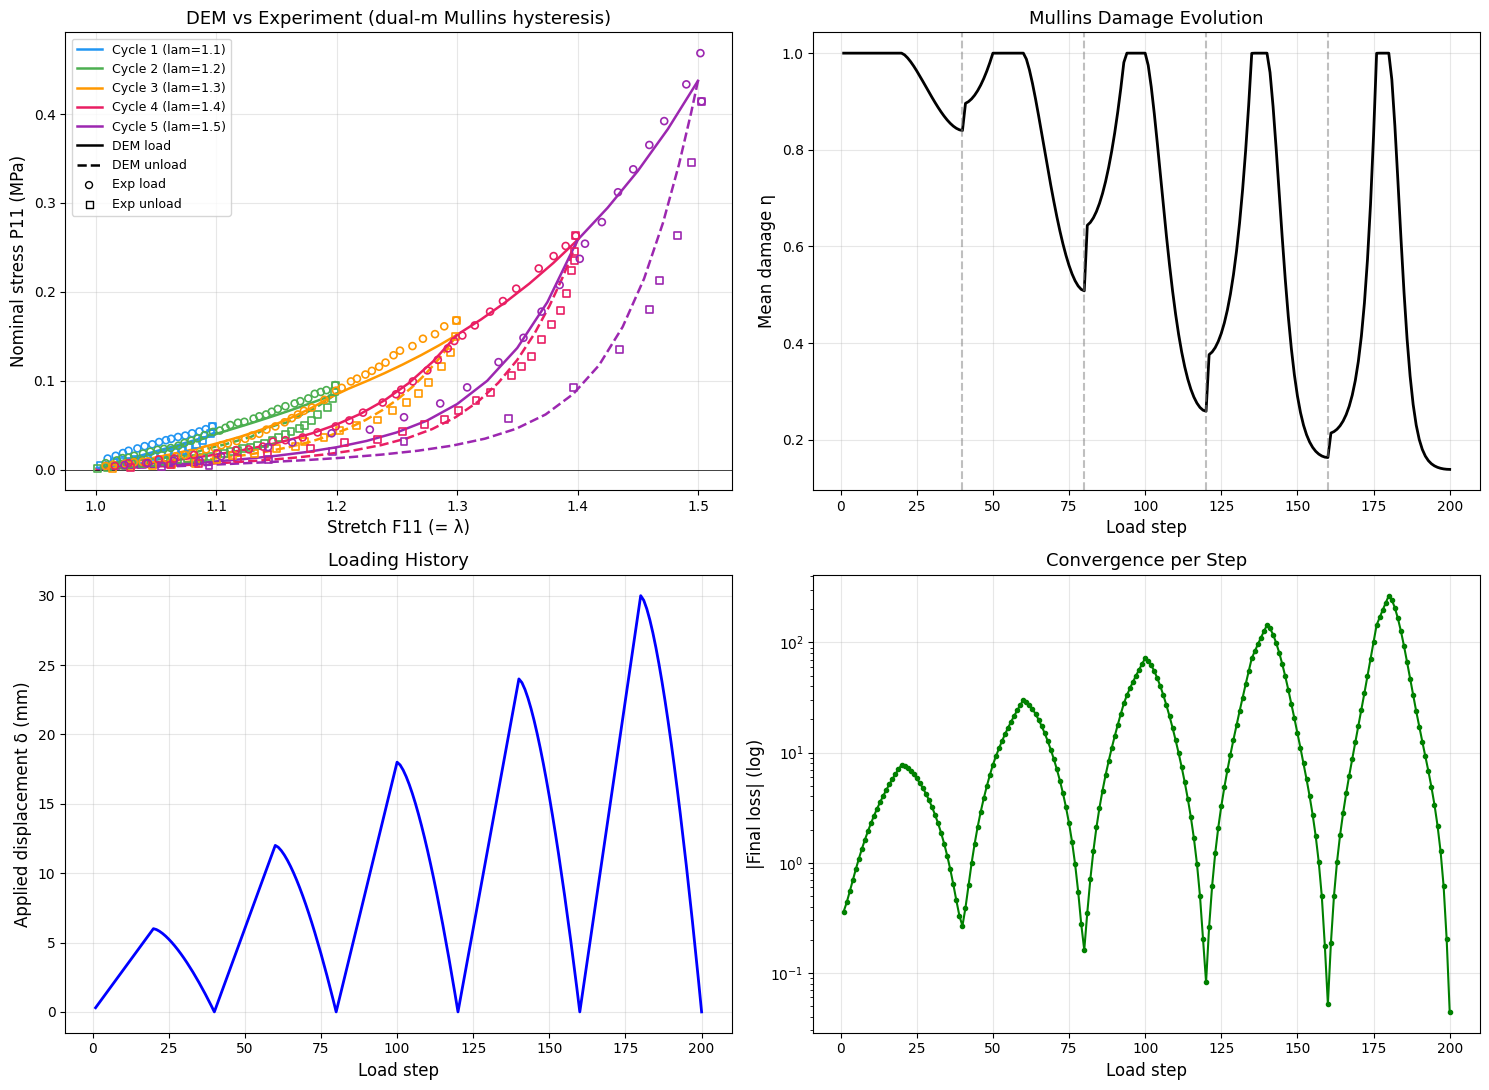

In [48]:

import pandas as pd
from scipy.optimize import brentq as _brentq

def _load_exp(path):
    with open(path, 'rb') as f:
        magic = f.read(4)
    is_excel = (magic[:2] == b'PK') or (magic[:4] == b'\xd0\xcf\x11\xe0')
    if is_excel:
        raw = pd.read_excel(path, header=None)
    else:
        for enc in ('utf-8', 'gbk', 'gb2312', 'utf-8-sig', 'latin-1'):
            try:
                raw = pd.read_csv(path, header=None, encoding=enc)
                break
            except Exception:
                continue

    cycles = []
    for k in range(5):
        lam = raw.iloc[:, 2*k  ].dropna().values.astype(float)
        sig = raw.iloc[:, 2*k+1].dropna().values.astype(float)
        n   = min(len(lam), len(sig))
        lam, sig = lam[:n], sig[:n]
        pi  = int(np.argmax(lam))
        cycles.append(dict(
            lam_load   = lam[:pi+1],  sig_load   = sig[:pi+1],
            lam_unload = lam[pi:],    sig_unload = sig[pi:],
        ))
    return cycles

cycles_data = _load_exp(r"E:\QL\DEM_HGO\codes\new\NEW\mullins.csv")

F11_arr = np.array(results['F11'])
P11_arr = np.array(results['P11'])
phases  = results['phase']
steps   = np.array(results['step'])
etas    = np.array(results['eta_mean'])

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# ===== (a) Stress-stretch with analytical reference =====
ax = axes[0, 0]


cycle_colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']
cycle_labels = [f'Cycle {ci+1} (lam={1 + delta_peaks[ci]/L_geom:.1f})'
                for ci in range(n_cycles)]

step_idx = 0
for ci in range(n_cycles):
    n_seg = 2 * n_cycle
    idx_load   = list(range(step_idx, step_idx + n_cycle))
    idx_unload = list(range(step_idx + n_cycle - 1, step_idx + n_seg))   


    ax.plot(F11_arr[idx_load], P11_arr[idx_load], '-',
            color=cycle_colors[ci], linewidth=1.8,
            label=cycle_labels[ci])
    ax.plot(F11_arr[idx_unload], P11_arr[idx_unload], '--',
            color=cycle_colors[ci], linewidth=1.8)


    cyc = cycles_data[ci]
    ax.scatter(cyc['lam_load'],   cyc['sig_load'],
               facecolors='none', edgecolors=cycle_colors[ci],
               marker='o', s=25, linewidths=1.2, zorder=5)
    ax.scatter(cyc['lam_unload'], cyc['sig_unload'],
               facecolors='none', edgecolors=cycle_colors[ci],
               marker='s', s=25, linewidths=1.2, zorder=5)

    step_idx += n_seg


ax.plot([], [], 'k-',  linewidth=1.8, label='DEM load')
ax.plot([], [], 'k--', linewidth=1.8, label='DEM unload')
ax.scatter([], [], facecolors='none', edgecolors='k', marker='o', s=25, label='Exp load')
ax.scatter([], [], facecolors='none', edgecolors='k', marker='s', s=25, label='Exp unload')

ax.set_xlabel('Stretch F11 (= λ)', fontsize=12)
ax.set_ylabel('Nominal stress P11 (MPa)', fontsize=12)
ax.set_title('DEM vs Experiment (dual-m Mullins hysteresis)', fontsize=13)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.5)


ax = axes[0, 1]
ax.plot(steps, etas, 'k-', linewidth=2)
for i in range(1, n_cycles):
    ax.axvline(i * 2 * n_cycle, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Load step', fontsize=12)
ax.set_ylabel('Mean damage η', fontsize=12)
ax.set_title('Mullins Damage Evolution', fontsize=13)
ax.grid(True, alpha=0.3)


ax = axes[1, 0]
ax.plot(steps, results['delta'], 'b-', linewidth=2)
ax.set_xlabel('Load step', fontsize=12)
ax.set_ylabel('Applied displacement δ (mm)', fontsize=12)
ax.set_title('Loading History', fontsize=13)
ax.grid(True, alpha=0.3)

# ===== (d) Loss per step =====
ax = axes[1, 1]
ax.semilogy(steps, np.abs(results['loss_final']), 'g-o', markersize=3)
ax.set_xlabel('Load step', fontsize=12)
ax.set_ylabel('|Final loss| (log)', fontsize=12)
ax.set_title('Convergence per Step', fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('DEM_HGO_Mullins_dual_m.png', dpi=120, bbox_inches='tight')
plt.show()

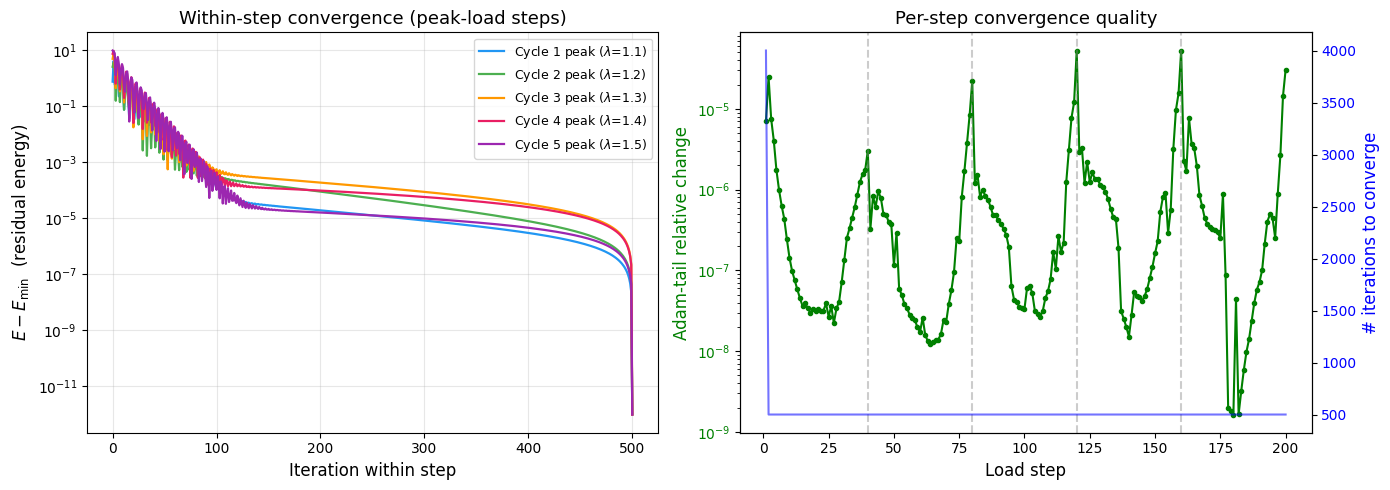

In [49]:
# ============================================================
#  Loss 收敛诊断:  (1) 代表步内收敛   +   (3) 逐步收敛质量
#  注意: 需先重新运行上面的训练循环, 才会有 results['loss_hist']
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

assert results.get('loss_hist'), \
    "results['loss_hist'] 为空: 请先重新运行训练循环 (已加入 loss_hist 存储)。"

hist  = results['loss_hist']
steps = np.array(results['step'])
cycle_colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

# 各循环峰值步 (load 段末尾, 应变最大、最难收敛)
peak_idx = [ci * 2 * n_cycle + (n_cycle - 1) for ci in range(n_cycles)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ---- (1) 代表步内收敛 ----
for ci, k in enumerate(peak_idx):
    a = np.abs(hist[k])
    lam_pk = 1.0 + delta_peaks[ci] / L_geom
    ax1.semilogy(np.arange(len(a)), a - a.min() + 1e-12,
                 color=cycle_colors[ci], lw=1.6,
                 label=f'Cycle {ci+1} peak ($\\lambda$={lam_pk:.1f})')
ax1.set_xlabel('Iteration within step', fontsize=12)
ax1.set_ylabel(r'$E - E_{\min}$  (residual energy)', fontsize=12)
ax1.set_title('Within-step convergence (peak-load steps)', fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(True, which='both', alpha=0.3)

# ---- (3) 逐步收敛质量 ----
# 末尾一点是 L-BFGS 一次性结果, 计算 Adam 收敛紧致度时排除它,
# 否则 L-BFGS 的最终大幅下降会被误判为"没收敛"。
n_iter, adam_tail = [], []
for h in hist:
    a = np.abs(h)
    n_iter.append(len(a))
    adam = a[:-1] if len(a) >= 2 else a
    ref = adam[-11] if len(adam) >= 11 else adam[0]
    adam_tail.append(abs(adam[-1] - ref) / max(abs(adam[-1]), 1e-12))

ax2.semilogy(steps, adam_tail, 'g-o', ms=3)
ax2.set_xlabel('Load step', fontsize=12)
ax2.set_ylabel('Adam-tail relative change', color='g', fontsize=12)
ax2.tick_params(axis='y', labelcolor='g')
for i in range(1, n_cycles):
    ax2.axvline(i * 2 * n_cycle, color='gray', linestyle='--', alpha=0.4)

ax2b = ax2.twinx()
ax2b.plot(steps, n_iter, 'b-', alpha=0.55, lw=1.5)
ax2b.set_ylabel('# iterations to converge', color='b', fontsize=12)
ax2b.tick_params(axis='y', labelcolor='b')
ax2.set_title('Per-step convergence quality', fontsize=13)

plt.tight_layout()
plt.savefig('DEM_HGO_Mullins_convergence.png', dpi=120, bbox_inches='tight')
plt.show()


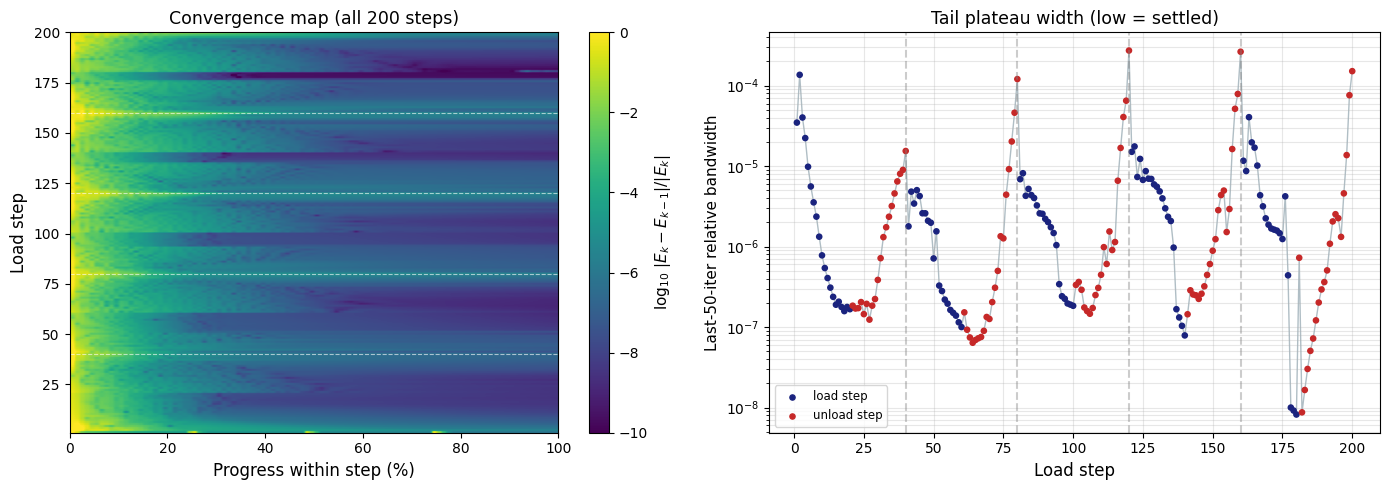

In [50]:
# ============================================================
#  Loss 收敛诊断 v3: 全 200 步一张热图 + 末段平台带宽
#  只用上次训练已留在内存的 results['loss_hist'], 无需重训
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

assert results.get('loss_hist'), "kernel 里没有 loss_hist: 用上次训练的 results 即可, 不必重训。"

hist  = results['loss_hist']
steps = np.array(results['step'])
NG    = 100                                  # 归一化进度网格

M, band = np.full((len(hist), NG), np.nan), []
for i, h in enumerate(hist):
    a = np.abs(h)[:-1]                        # 去掉末尾 L-BFGS 单点
    if len(a) >= 3:
        rel = np.abs(np.diff(a)) / np.maximum(np.abs(a[1:]), 1e-12)
        xo  = np.linspace(0, 1, len(rel))
        M[i] = np.log10(np.clip(np.interp(np.linspace(0, 1, NG), xo, rel), 1e-12, None))
    tail = a[-min(50, len(a)):] if len(a) >= 2 else a       # 最后 50 代
    band.append((tail.max() - tail.min()) / max(abs(tail.mean()), 1e-12))
band = np.array(band)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ---- (A) 热图: 行=载荷步, 列=该步进度0→100%, 颜色=相邻变化(越暗越收敛) ----
im = ax1.imshow(M, aspect='auto', origin='lower', cmap='viridis',
                extent=[0, 100, steps.min(), steps.max()], vmin=-10, vmax=0)
cb = fig.colorbar(im, ax=ax1); cb.set_label(r'$\log_{10}\,|E_k-E_{k-1}|/|E_k|$', fontsize=11)
for i in range(1, n_cycles):
    ax1.axhline(i * 2 * n_cycle, color='w', ls='--', lw=0.8, alpha=0.6)
ax1.set_xlabel('Progress within step (%)', fontsize=12)
ax1.set_ylabel('Load step', fontsize=12)
ax1.set_title('Convergence map (all 200 steps)', fontsize=12.5)

# ---- (B) 末段平台带宽: 每步最后50代相对波动, 低=收敛干净 ----
colors = ['#1A237E' if p == 'load' else '#C62828' for p in results['phase']]
ax2.semilogy(steps, np.maximum(band, 1e-12), '-', color='#B0BEC5', lw=1.0, zorder=1)
ax2.scatter(steps, np.maximum(band, 1e-12), c=colors, s=14, zorder=2)
for i in range(1, n_cycles):
    ax2.axvline(i * 2 * n_cycle, color='gray', ls='--', alpha=0.4)
ax2.scatter([], [], c='#1A237E', s=14, label='load step')
ax2.scatter([], [], c='#C62828', s=14, label='unload step')
ax2.set_xlabel('Load step', fontsize=12)
ax2.set_ylabel('Last-50-iter relative bandwidth', fontsize=11)
ax2.set_title('Tail plateau width (low = settled)', fontsize=12.5)
ax2.legend(fontsize=8.5); ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('DEM_HGO_Mullins_convergence_v3.png', dpi=120, bbox_inches='tight')
plt.show()

In [51]:

# """
# 3D Consistent Parameter Fitting for HGO + Double m Mullins Effect (Optimized Version for Unloading Section Accuracy)

# """

# import sys
# import numpy as np
# import pandas as pd
# import matplotlib
# matplotlib.use('Agg')
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# from scipy.optimize import least_squares, differential_evolution, root
# from scipy.special import erf as sp_erf
# import warnings
# warnings.filterwarnings('ignore')

# # ─────────────────────────────────────────────────────────
# # 0. Fixed parameters
# # ─────────────────────────────────────────────────────────
# GAMMA_DEG = 49.2
# GAMMA_RAD = np.deg2rad(GAMMA_DEG)
# COS_G     = np.cos(GAMMA_RAD)
# SIN_G     = np.sin(GAMMA_RAD)
# KAPPA     = 0.0

# D_FIXED   = 0.1          

# FIT_BETA  = False       
# USE_GLOBAL = True        

# # ─────────────────────────────────────────────────────────
# # 1. Read data
# # ─────────────────────────────────────────────────────────
# def load_csv(path):
#     with open(path, 'rb') as f:
#         magic = f.read(4)
#     is_excel = (magic[:2] == b'PK') or (magic[:4] == b'\xd0\xcf\x11\xe0')

#     if is_excel:
#         raw = pd.read_excel(path, header=None)
#         print("  [Excel 格式]")
#     else:
#         for enc in ('utf-8', 'gbk', 'gb2312', 'utf-8-sig', 'latin-1'):
#             try:
#                 raw = pd.read_csv(path, header=None, encoding=enc)
#                 break
#             except Exception:
#                 continue
#         else:
#             raise RuntimeError(f"无法读取文件: {path}")

#     n_rows, n_cols = raw.shape
#     if n_cols >= 2 and n_cols % 2 == 0 and n_rows > n_cols:
#         fmt, n_cycles = 'A', n_cols // 2
#         print(f"  [格式A: 列方向, {n_cycles} 循环 x 2 列]")
#     elif n_rows >= 10 and n_rows % 2 == 0:
#         fmt, n_cycles = 'B', n_rows // 2
#         print(f"  [格式B: 行方向, {n_cycles} 循环 x 2 行]")
#     else:
#         raise RuntimeError(f"无法识别数据排布: 形状={raw.shape}")

#     cycles = []
#     for k in range(n_cycles):
#         if fmt == 'A':
#             lam = raw.iloc[:, 2 * k].dropna().values.astype(float)
#             sig = raw.iloc[:, 2 * k + 1].dropna().values.astype(float)
#         else:
#             lam = raw.iloc[2 * k, :].dropna().values.astype(float)
#             sig = raw.iloc[2 * k + 1, :].dropna().values.astype(float)

#         n = min(len(lam), len(sig))
#         lam, sig = lam[:n], sig[:n]
#         pi = int(np.argmax(lam))
#         cycles.append(dict(
#             lam_load=lam[:pi + 1], sig_load=sig[:pi + 1],
#             lam_unload=lam[pi:],   sig_unload=sig[pi:],
#             lam_peak=lam[pi],
#         ))
#         print(f"  Cycle {k+1}: {n} pts | lam_peak={lam[pi]:.4f} | sig_peak={sig[pi]:.4f} MPa")
#     return cycles


# def _psi_dev_3d(lam1, lam2, lam3, C10, k1, k2):
#     J = lam1 * lam2 * lam3
#     lb1 = lam1 * J ** (-1. / 3.)
#     lb2 = lam2 * J ** (-1. / 3.)
#     lb3 = lam3 * J ** (-1. / 3.)
#     I1 = lb1**2 + lb2**2 + lb3**2

#     I4 = lb1**2 * COS_G**2 + lb2**2 * SIN_G**2
#     E4 = max(I4 - 1., 0.)
#     return C10 * (I1 - 3.) + (k1 / (2. * k2)) * 2. * (np.exp(k2 * E4 ** 2) - 1.)

# def _psi_vol_3d(lam1, lam2, lam3, D_p):

#     safe_D_p = D_p if abs(D_p) > 1e-9 else 0.1
#     J = lam1 * lam2 * lam3
#     return (1. / safe_D_p) * ((J ** 2 - 1.) / 2. - np.log(J))

# def _eta(psi_d, psi_max, is_loading, r_mul, m_load, m_unload, beta):
#     m_cur = m_load if is_loading else m_unload
#     denom = m_cur + beta * psi_max + 1e-12
#     arg = np.clip((psi_max - psi_d) / denom, 0., 5.)
#     return 1. - sp_erf(arg) / r_mul

# def find_lam23_virgin(lam1, C10, k1, k2, D_p):

#     eps = 1e-6
#     def residuals(x):
#         l2, l3 = x
    
#         pp2 = _psi_dev_3d(lam1, l2+eps, l3, C10, k1, k2) + _psi_vol_3d(lam1, l2+eps, l3, D_p)
#         pm2 = _psi_dev_3d(lam1, l2-eps, l3, C10, k1, k2) + _psi_vol_3d(lam1, l2-eps, l3, D_p)
#         P22 = (pp2 - pm2) / (2. * eps)
      
#         pp3 = _psi_dev_3d(lam1, l2, l3+eps, C10, k1, k2) + _psi_vol_3d(lam1, l2, l3+eps, D_p)
#         pm3 = _psi_dev_3d(lam1, l2, l3-eps, C10, k1, k2) + _psi_vol_3d(lam1, l2, l3-eps, D_p)
#         P33 = (pp3 - pm3) / (2. * eps)
#         return [P22, P33]
    

#     guess = 1.0 / np.sqrt(max(lam1, 1e-3))
#     sol = root(residuals, x0=[guess, guess])
#     return sol.x[0], sol.x[1]

# def compute_P11(lam1, lam2, lam3, C10, k1, k2, D_p, psi_max, is_loading, r_mul, m_load, m_unload, beta=0.0):
#     psi_d0 = _psi_dev_3d(lam1, lam2, lam3, C10, k1, k2)
#     eta = _eta(psi_d0, psi_max, is_loading, r_mul, m_load, m_unload, beta)
#     eps = max(abs(lam1), 1.0) * 1e-5
#     dpd = (_psi_dev_3d(lam1 + eps, lam2, lam3, C10, k1, k2) -
#            _psi_dev_3d(lam1 - eps, lam2, lam3, C10, k1, k2)) / (2. * eps)
#     dpv = (_psi_vol_3d(lam1 + eps, lam2, lam3, D_p) -
#            _psi_vol_3d(lam1 - eps, lam2, lam3, D_p)) / (2. * eps)
#     return eta * dpd + dpv

# def simulate_cycles(params, cycles_data):
#     if FIT_BETA:
#         C10, k1, k2, r_mul, m_load, m_unload, beta = params
#     else:
#         C10, k1, k2, r_mul, m_load, m_unload = params
#         beta = 0.0
    
#     D_p = D_FIXED 

#     global_psi_max = 0.0
#     results = []
#     for cyc in cycles_data:
#         P11_load, local_psi = [], global_psi_max
#         for lam1 in cyc['lam_load']:
#             l2, l3 = find_lam23_virgin(lam1, C10, k1, k2, D_p)
#             P11 = compute_P11(lam1, l2, l3, C10, k1, k2, D_p,
#                               local_psi, True, r_mul, m_load, m_unload, beta)
#             local_psi = max(local_psi, _psi_dev_3d(lam1, l2, l3, C10, k1, k2))
#             P11_load.append(P11)
#         global_psi_max = local_psi

#         P11_unload = []
#         for lam1 in cyc['lam_unload']:
#             l2, l3 = find_lam23_virgin(lam1, C10, k1, k2, D_p)
#             P11 = compute_P11(lam1, l2, l3, C10, k1, k2, D_p,
#                               global_psi_max, False, r_mul, m_load, m_unload, beta)
#             P11_unload.append(P11)

#         results.append(dict(P11_load=np.asarray(P11_load),
#                             P11_unload=np.asarray(P11_unload)))
#     return results


# def _n_resid(cycles_data):
  
#     return sum(len(c['sig_load']) + len(c['sig_unload']) for c in cycles_data)

# def residuals(params, cycles_data, n_resid):
#     try:
#         sim = simulate_cycles(params, cycles_data)
#     except Exception:
#         return np.full(n_resid, 1e3)

#     parts = []
#     for cyc, res in zip(cycles_data, sim):
#         parts.append(res['P11_load'] - cyc['sig_load'])
#         parts.append(res['P11_unload'] - cyc['sig_unload'])
    
#     out = np.concatenate(parts)
#     out[~np.isfinite(out)] = 1e3
#     return out

# def objective(params, cycles_data):
#     return float(np.sum(residuals(params, cycles_data, _n_resid(cycles_data)) ** 2))



# def _bounds_names():
#     if FIT_BETA:

#         lb = [1e-3, 0.01, 0.01, 1.001, 1e-3, 1e-3, 0.05] 
#         ub = [2.0,  50.0, 20.0, 8.0,   30.0, 30.0, 10.0] 
#         names = ['C10', 'k1', 'k2', 'r', 'm_load', 'm_unload', 'beta']
#     else:
#         lb = [1e-3, 0.01, 0.01, 1.001, 1e-3, 1e-3]
#         ub = [2.0,  50.0, 20.0, 8.0,   30.0, 30.0]
#         names = ['C10', 'k1', 'k2', 'r', 'm_load', 'm_unload']
#     return np.array(lb), np.array(ub), names

# def fit_parameters(cycles_data, x0=None, verbose=True):
#     lb, ub, names = _bounds_names()
#     n_resid = _n_resid(cycles_data)

#     if USE_GLOBAL and x0 is None:
#         if verbose: print("\n[Phase 1] 差分进化全局搜索 (热启动)...")
#         gen_c, best = [0], [np.inf]
#         def cb(xk, conv):
#             gen_c[0] += 1
#             v = objective(xk, cycles_data)
#             best[0] = min(best[0], v)
#             if verbose and gen_c[0] % 20 == 0:
#                 print(f"  [DE] gen={gen_c[0]:4d}  SSE={best[0]:.6e}")
#         de = differential_evolution(
#             objective, list(zip(lb, ub)), args=(cycles_data,),
#             strategy='best1bin', maxiter=100, popsize=18,
#             tol=1e-10, mutation=(0.4, 1.4), recombination=0.85,
#             seed=42, callback=cb, polish=False, disp=False, workers=1,
#         )
#         x0 = de.x
#         if verbose: print(f"  [DE] 全局完成  SSE={de.fun:.6e}")
#     elif x0 is None:
#         x0 = np.array([0.05, 1.0, 1.0, 2.0, 1.0, 1.0] + ([0.0] if FIT_BETA else []))
#     x0 = np.clip(np.asarray(x0, float), lb, ub)

#     if verbose: print("\n[Phase 2] least_squares 信赖域最小二乘 (TRF) 高精度精修...")
#     sol = least_squares(
#         residuals, x0, args=(cycles_data, n_resid),
#         bounds=(lb, ub), method='trf', x_scale='jac', loss='linear',
#         ftol=1e-12, xtol=1e-12, gtol=1e-12, max_nfev=30000,
#         verbose=2 if verbose else 0,
#     )

#     p = sol.x
#     rmse = np.sqrt(np.mean(residuals(p, cycles_data, n_resid) ** 2))
#     if verbose:
#         print(f"  [TRF] 精修完成: status={sol.status}, nfev={sol.nfev}, RMSE={rmse:.6f} MPa")

#     p = list(p)
#     if not FIT_BETA:
#         p += [0.0]; names = names + ['beta']
#     param_dict = dict(zip(names, p))
#     param_dict['D_p'] = D_FIXED  
#     return param_dict, rmse


# def print_results(param_dict, cycles_data, rmse):
#     units = {'C10': 'MPa', 'k1': 'MPa', 'k2': '-', 'D_p': 'MPa-1',
#              'r': '-', 'm_load': 'MPa', 'm_unload': 'MPa', 'beta': '-'}
#     sep = "=" * 62
#     print(f"\n{sep}\n  拟合参数结果 (卸载精度微调优化版)\n{sep}")
#     for k in ['C10', 'k1', 'k2', 'r', 'm_load', 'm_unload', 'beta']:
#         print(f"  {k:<14}  {param_dict[k]:>13.6f}   {units.get(k,'')}")
#     print("-" * 62)
#     print(f"  {'D_p(fixed)':<14}  {D_FIXED:>13.6f}   MPa-1")
#     print(f"  {'gamma(fixed)':<14}  {GAMMA_DEG:>13.2f}   deg")
#     print(f"  {'kappa(fixed)':<14}  {KAPPA:>13.4f}   -")
#     print("-" * 62)
#     print(f"  Total RMSE      {rmse:>13.6f}   MPa\n{sep}")

#     pv = [param_dict[k] for k in ['C10', 'k1', 'k2', 'r', 'm_load', 'm_unload']]
#     if FIT_BETA:
#         pv.append(param_dict['beta'])
#     sim = simulate_cycles(pv, cycles_data)

#     print("\n  逐循环单精度分析 RMSE (MPa):")
#     for k, (cyc, res) in enumerate(zip(cycles_data, sim)):
#         el = np.sqrt(np.mean((res['P11_load'] - cyc['sig_load']) ** 2))
#         eu = np.sqrt(np.mean((res['P11_unload'] - cyc['sig_unload']) ** 2))
#         print(f"    Cycle {k+1}: 加载段 RMSE = {el:.5f} | 卸载段 RMSE = {eu:.5f}")
#     return sim


# def plot_results(cycles_data, sim, param_dict, rmse, save_path='HGO_Mullins_fit_optimized.png'):
#     n = len(cycles_data)
#     cols = min(n, 3)
#     rows = (n + cols - 1) // cols + 1
#     pal = ['#1565C0', '#2E7D32', '#E65100', '#B71C1C', '#4A148C']
#     palU = ['#90CAF9', '#A5D6A7', '#FFCC80', '#EF9A9A', '#CE93D8']

#     fig = plt.figure(figsize=(5.8 * cols, 4.8 * rows))
#     gs = gridspec.GridSpec(rows, cols, hspace=0.50, wspace=0.30)

#     ax0 = fig.add_subplot(gs[0, :])
#     for k, (cyc, res) in enumerate(zip(cycles_data, sim)):
#         c, cu = pal[k % len(pal)], palU[k % len(palU)]
#         ax0.plot(cyc['lam_load'], cyc['sig_load'], 'o', ms=3.5, color=c, label=f'Exp C{k+1}')
#         ax0.plot(cyc['lam_unload'], cyc['sig_unload'], 's', ms=3.5, color=cu)
#         ax0.plot(cyc['lam_load'], res['P11_load'], '-', lw=2.0, color=c, label=f'Fit C{k+1}')
#         ax0.plot(cyc['lam_unload'], res['P11_unload'], '--', lw=1.7, color=c)
#     ax0.set_xlabel('Stretch  lambda', fontsize=11)
#     ax0.set_ylabel('Nominal stress  P11 (MPa)', fontsize=11)
#     ax0.set_title('Optimized HGO + Dual-m Mullins', fontsize=12, fontweight='bold')
#     ax0.legend(ncol=max(n, 1), fontsize=8, loc='upper left')
#     ax0.grid(True, alpha=0.25); ax0.axhline(0, color='k', lw=0.5)

#     for k, (cyc, res) in enumerate(zip(cycles_data, sim)):
#         c, cu = pal[k % len(pal)], palU[k % len(palU)]
#         ax = fig.add_subplot(gs[1 + k // cols, k % cols])
#         ax.plot(cyc['lam_load'], cyc['sig_load'], 'o', ms=4.5, color=c, label='Exp load')
#         ax.plot(cyc['lam_unload'], cyc['sig_unload'], 's', ms=4.5, color=cu, label='Exp unload')
#         ax.plot(cyc['lam_load'], res['P11_load'], '-', lw=2.2, color=c, label='Fit load')
#         ax.plot(cyc['lam_unload'], res['P11_unload'], '--', lw=1.8, color=c, label='Fit unload')
#         el = np.sqrt(np.mean((res['P11_load'] - cyc['sig_load']) ** 2))
#         eu = np.sqrt(np.mean((res['P11_unload'] - cyc['sig_unload']) ** 2))
#         ax.set_title(f'Cycle {k+1}  ld={el:.4f}  ul={eu:.4f} MPa', fontsize=8.5)
#         ax.set_xlabel('lambda', fontsize=10)
#         ax.set_ylabel('P11 (MPa)', fontsize=10)
#         ax.legend(fontsize=7.5, loc='upper left')
#         ax.grid(True, alpha=0.25); ax.axhline(0, color='k', lw=0.5)

#     fig.suptitle(
#         f'C10={param_dict["C10"]:.4f} MPa  k1={param_dict["k1"]:.4f} MPa  '
#         f'k2={param_dict["k2"]:.4f}  D_p={D_FIXED:.4f} MPa-1 (fixed)  r={param_dict["r"]:.4f}\n'
#         f'm_load={param_dict["m_load"]:.4f} MPa  m_unload={param_dict["m_unload"]:.4f} MPa  '
#         f'beta={param_dict["beta"]:.4f}  gamma={GAMMA_DEG} deg (fixed)  '
#         f'Total RMSE={rmse:.5f} MPa',
#         fontsize=8.5, y=1.01)
#     plt.savefig(save_path, dpi=150, bbox_inches='tight')
#     print(f"\n图像已成功导出至: {save_path}")


# def save_params(param_dict, rmse, path='fitted_params_optimized.csv'):
#     units = {'C10': 'MPa', 'k1': 'MPa', 'k2': '-', 'r': '-',
#              'm_load': 'MPa', 'm_unload': 'MPa', 'beta': '-'}
#     rows = [{'Parameter': k, 'Value': f'{param_dict[k]:.8g}', 'Unit': units.get(k, '')}
#             for k in ['C10', 'k1', 'k2', 'r', 'm_load', 'm_unload', 'beta']]
#     rows += [
#         {'Parameter': 'D_p', 'Value': f'{D_FIXED:.8g}', 'Unit': 'MPa-1 (fixed)'},
#         {'Parameter': 'RMSE_total', 'Value': f'{rmse:.8g}', 'Unit': 'MPa'},
#         {'Parameter': 'gamma_deg', 'Value': str(GAMMA_DEG), 'Unit': 'deg (fixed)'},
#         {'Parameter': 'kappa', 'Value': str(KAPPA), 'Unit': '- (fixed)'},
#     ]
#     pd.DataFrame(rows).to_csv(path, index=False)
#     print(f"数据参数已存盘: {path}")

# def main(data_path=None):
#     if data_path is None:
#         if len(sys.argv) >= 2 and not sys.argv[1].startswith('-') \
#                 and sys.argv[1].lower().endswith(('.csv', '.xlsx', '.xls')):
#             data_path = sys.argv[1]
#         else:
#             data_path = r"E:\QL\DEM_HGO\codes\new\NEW\mullins.csv"
#             print(f"未明确文件，使用当前默认数据源: {data_path}")

#     print(f"\n正在调入文件: {data_path}")
#     cycles_data = load_csv(data_path)
#     param_dict, rmse = fit_parameters(cycles_data, verbose=True)
#     sim = print_results(param_dict, cycles_data, rmse)
#     plot_results(cycles_data, sim, param_dict, rmse)
#     save_params(param_dict, rmse)

# if __name__ == '__main__':
#     main()


## 15. 说明

### 双 m Mullins 的物理含义

- $m_{load} = 0.06$ MPa：加载段损伤发展较慢（η 在接近 ψ_max 时才显著下降）
- $m_{unload} = 0.03$ MPa：卸载段损伤更快（η 更小 → 应力更低 → 曲线更软）
- **再加载段**使用 $m_{load}$（因为 is_loading=True），所以 η 比卸载时更大 → 曲线更高

这产生了经典的 Mullins 滞回环：**再加载曲线在卸载曲线上方**。

### 参数调节指南

| 效果 | 调节方式 |
|---|---|
| 增大滞回环宽度 | 增大 $m_{load}/m_{unload}$ 比值 |
| 增大整体软化程度 | 减小 $r$（接近 1） |
| 减小软化 | 增大 $r$ 或增大 $m$ |

### 与 Abaqus 对比

Abaqus 内置 Ogden-Roxburgh 只有单 m，无滞回。要对比双 m 版本，需要 UMAT 子程序。
单 m 版本（$m_{load} = m_{unload} = 0.04$）可直接与 Abaqus 内置实现对比。